### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from function_to_normalize_sgrna_lfc import *

In [54]:
read_count = pd.read_csv("./tkov3_data/matrix-reads-by-gRNA-RPE1-drugZ.txt", sep ='\t')
read_count[['gene', 'sgRNA']] = read_count['sgRNA'].str.split('_', n = 1, expand=True)
read_count = read_count.drop(columns=['GENE', 'gene'])
read_count = read_count.rename(columns={'sgRNA':'spacer'})

# filtered out sgRNA with less than 30 reads in T0
read_count = read_count[read_count['RPE1_T0'] > 30]

# drop LOPRIMER data
# read_count = read_count.drop(columns = ['RPE1_T3A_CTRL_LOPRIMER', 'RPE1_T3A_ENTI_LOPRIMER'])

display(list(read_count))
read_count

['spacer',
 'RPE1_T0',
 'RPE1_T3A_CTRL_LOPRIMER',
 'RPE1_T3A_CTRL',
 'RPE1_T3A_ENTI_LOPRIMER',
 'RPE1_T3A_ENTI',
 'RPE1_T3A_GEMC',
 'RPE1_T3A_VINC',
 'RPE1_T3B_CTRL',
 'RPE1_T3B_ENTI',
 'RPE1_T3B_GEMC',
 'RPE1_T3B_VINC']

,spacer,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
0,ACTGGCGCCATCGAGAGCCA,164,83,93,33,50,105,39,44,118,33,77
1,CAAGAGAAAGACCACGAGCA,492,416,288,275,262,277,286,222,401,216,228
2,GCTCAGCTGGGTCCATCCTG,258,54,49,38,25,101,28,5,57,52,32
3,GTCGAGCTGATTCTGAGCGA,487,668,360,462,307,353,278,290,565,193,209
4,AGTTATGTTAGGTATACCCG,149,242,133,193,187,165,133,140,379,87,189
...,...,...,...,...,...,...,...,...,...,...,...,...
71085,GGTCTTCCCGACGATGACGC,320,345,160,154,108,150,146,59,167,112,82
71086,TATCGATTCCAATTCAGCGG,298,265,183,359,339,246,234,153,317,220,195
71087,TATTCTGATTACACCCGAGG,384,603,395,372,361,353,329,243,482,301,345
71088,TCTAGAGGATAGAATGGCGC,399,414,266,228,164,244,165,138,418,202,158


In [55]:
# import library data
library_data = pd.read_csv("../../CRISPR-KO-library-refinement-pipeline/public_crispr_library/tkov3_guide_sequence.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

# import common essential genes
list_common_essential = import_common_essential()

(71090, 3)

In [56]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,492,416,288,275,262,277,286,222,401,216,228
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,258,54,49,38,25,101,28,5,57,52,32
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,164,83,93,33,50,105,39,44,118,33,77
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,487,668,360,462,307,353,278,290,565,193,209
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,190,146,96,24,36,35,59,53,72,22,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,180,356,232,343,281,257,398,206,407,131,201
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,617,484,433,423,418,447,402,373,751,314,407
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,585,455,235,412,331,325,281,202,392,263,208


In [70]:
# we log transformed the raw read counts (log2(counts + 1))

# separate plasmid count into a new column
# plasmid_count = read_count['RPE1_T0']
# plasmid_count

# main log transformed read count
# log_transformed_read_count = read_count.drop(columns=['RPE1_T0'])
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,RPE1_T0,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,8.945444,8.703904,8.174926,8.108524,8.038919,8.118941,8.164907,7.800900,8.651052,7.761551,7.839204
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,8.016808,5.781360,5.643856,5.285402,4.700440,6.672425,4.857981,2.584963,5.857981,5.727920,5.044394
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,7.366322,6.392317,6.554589,5.087463,5.672425,6.727920,5.321928,5.491853,6.894818,5.087463,6.285402
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,8.930737,9.385862,8.495855,8.854868,8.266787,8.467606,8.124121,8.184875,9.144658,7.599913,7.714246
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,7.577429,7.199672,6.599913,4.643856,5.209453,5.169925,5.906891,5.754888,6.189825,4.523562,4.857981
...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,7.499846,8.479780,7.864186,8.426265,8.139551,8.011227,8.640245,7.693487,8.672425,7.044394,7.658211
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,9.271463,8.921841,8.761551,8.727920,8.710806,8.807355,8.654636,8.546894,9.554589,8.299208,8.672425
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,9.194757,8.832890,7.882643,8.689998,8.375039,8.348728,8.139551,7.665336,8.618386,8.044394,7.707359


In [71]:
log_transformed_read_count_no_T0 = log_transformed_read_count.drop(columns=['RPE1_T0'])

# normalized the data across cell lines by centering around the median of guides targeting non-essential genes (in this case we cannot used control guides as it targets a gene instead of non-targeting)
# controls in TKOv3 are EGFP, LacZ, and luciferase
median_non_essential = np.median(log_transformed_read_count_no_T0[~log_transformed_read_count_no_T0.index.get_level_values(2).isin(list_common_essential)])
display(median_non_essential)

normalized_read_count = log_transformed_read_count_no_T0 - median_non_essential
display(normalized_read_count)

np.float64(7.658211482751795)

,,,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,1.045692,0.516714,0.450313,0.380708,0.460730,0.506695,0.142688,0.992840,0.103340,0.180992
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.876852,-2.014355,-2.372809,-2.957772,-0.985786,-2.800230,-5.073249,-1.800230,-1.930291,-2.613817
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-1.265894,-1.103623,-2.570749,-1.985786,-0.930291,-2.336283,-2.166358,-0.763394,-2.570749,-1.372809
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,1.727651,0.837644,1.196657,0.608575,0.809394,0.465910,0.526664,1.486447,-0.058299,0.056034
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.458539,-1.058299,-3.014355,-2.448758,-2.488286,-1.751321,-1.903324,-1.468387,-3.134650,-2.800230
...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.821569,0.205975,0.768053,0.481340,0.353016,0.982033,0.035275,1.014214,-0.613817,0.000000
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,1.263629,1.103340,1.069709,1.052595,1.149143,0.996425,0.888683,1.896377,0.640997,1.014214
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,1.174679,0.224432,1.031786,0.716828,0.690517,0.481340,0.007124,0.960174,0.386183,0.049148


In [72]:
# compute sgRNA log fold change by subtracting the log-transformed normalized count from the plasmid library
RPE1_T0 = log_transformed_read_count['RPE1_T0'] - median_non_essential

sgrna_lfc = normalized_read_count.subtract(RPE1_T0.values, axis=0)
sgrna_lfc

,,,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.241540,-0.770518,-0.836919,-0.906525,-0.826503,-0.780537,-1.144544,-0.294392,-1.183893,-1.106240
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-2.235449,-2.372952,-2.731406,-3.316369,-1.344383,-3.158827,-5.431846,-2.158827,-2.288888,-2.972414
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.974005,-0.811733,-2.278859,-1.693897,-0.638402,-2.044394,-1.874469,-0.471504,-2.278859,-1.080920
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.455125,-0.434882,-0.075869,-0.663951,-0.463132,-0.806616,-0.745862,0.213921,-1.330824,-1.216492
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.377756,-0.977516,-2.933573,-2.367975,-2.407504,-1.670538,-1.822541,-1.387604,-3.053867,-2.719448
...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.979934,0.364340,0.926419,0.639705,0.511381,1.140399,0.193641,1.172579,-0.455452,0.158366
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.349622,-0.509912,-0.543543,-0.560657,-0.464108,-0.616827,-0.724569,0.283126,-0.972255,-0.599038
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.361867,-1.312114,-0.504759,-0.819717,-0.846029,-1.055206,-1.529421,-0.576371,-1.150363,-1.487398


In [ ]:
# check fold change of control sgRNAs
# EGFP = sgrna_lfc[sgrna_lfc.index.get_level_values(2).isin(['EGFP'])].stack().values
# LacZ = sgrna_lfc[sgrna_lfc.index.get_level_values(2).isin(['LacZ'])].stack().values
# Luciferase = sgrna_lfc[sgrna_lfc.index.get_level_values(2).isin(['luciferase'])].stack().values

# plt.boxplot([EGFP, LacZ, Luciferase], labels = ['EGFP', 'LacZ', 'luciferase'])
# plt.axhline(y=0, color='r', linestyle='--')
# plt.ylabel('read count of guides targeting control genes')
# plt.show()

In [62]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
norm_sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc)
norm_sgrna_lfc_scaled

Scale factor:  2.6708962617499994


,,,RPE1_T3A_CTRL_LOPRIMER,RPE1_T3A_CTRL,RPE1_T3A_ENTI_LOPRIMER,RPE1_T3A_ENTI,RPE1_T3A_GEMC,RPE1_T3A_VINC,RPE1_T3B_CTRL,RPE1_T3B_ENTI,RPE1_T3B_GEMC,RPE1_T3B_VINC
sgRNA,spacer,gene,,,,,,,,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.090434,-0.288487,-0.313348,-0.339408,-0.309448,-0.292238,-0.428524,-0.110222,-0.443257,-0.414183
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-0.836966,-0.888448,-1.022655,-1.241669,-0.503345,-1.182684,-2.033716,-0.808278,-0.856974,-1.112890
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.364673,-0.303918,-0.853219,-0.634205,-0.239022,-0.765434,-0.701813,-0.176534,-0.853219,-0.404703
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.170402,-0.162823,-0.028406,-0.248587,-0.173399,-0.302002,-0.279255,0.080093,-0.498269,-0.455462
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.141434,-0.365988,-1.098348,-0.886585,-0.901384,-0.625460,-0.682371,-0.519528,-1.143387,-1.018178
...,...,...,...,...,...,...,...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.366893,0.136411,0.346857,0.239510,0.191464,0.426972,0.072500,0.439021,-0.170524,0.059293
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.130901,-0.190914,-0.203506,-0.209913,-0.173765,-0.230944,-0.271283,0.106004,-0.364018,-0.224283
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.135485,-0.491263,-0.188985,-0.306907,-0.316758,-0.395075,-0.572625,-0.215797,-0.430703,-0.556891


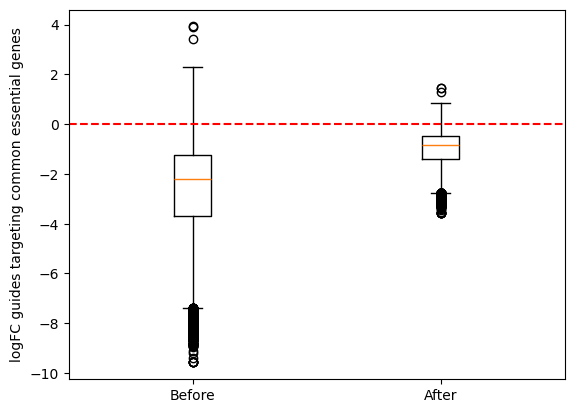

In [73]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, norm_sgrna_lfc_scaled, list_common_essential)

In [74]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(norm_sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.302955
1,sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.048763
2,sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.529674
3,sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,-0.189771
4,sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.738266
...,...,...,...,...
70056,sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.210840
70057,sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.189352
70058,sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.361049
70059,sgluciferase_8,CTATTCTGATTACACCCGAG,luciferase,-0.014003


In [75]:
np.median(lfc_norm_scaled_avg['mean'])

np.float64(-0.3738175498140546)

In [ ]:
lfc_norm_scaled_avg.to_csv("./output_normalized/tkov3_rpe1_normalized_lfc.csv", index=False)